<img src="https://raw.githubusercontent.com/IDEALLab/EngiOpt/codex/dcc26-workshop-notebooks/workshops/dcc26/assets/engibench_logo.png" width="600"/>

# Welcome to the DCC'26 EngiBench Workshop!

In the next 20 minutes you will **load an engineering-design benchmark, explore its data, and break its constraints on purpose**. No ML required yet — just Python and curiosity.

> **Colab users:** click **File ➜ Save a copy in Drive** before editing so your changes persist.

## Install dependencies (Colab / fresh env only)

Skip this if your local environment already has `engibench` installed.

In [81]:
# Colab/local dependency bootstrap
import subprocess, sys

IN_COLAB = "google.colab" in sys.modules
FORCE_INSTALL = False  # Set True to force install outside Colab

if IN_COLAB or FORCE_INSTALL:
    def _pip(pkgs): subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])
    _pip(["engibench[beams2d]", "matplotlib", "seaborn", "ipywidgets"])
    try:
        import torch
    except Exception:
        _pip(["torch", "torchvision"])
    print("Install complete.")
else:
    print("Using current environment. Set FORCE_INSTALL=True to install here.")

Using current environment. Set FORCE_INSTALL=True to install here.


## What is EngiBench?

<img src="https://raw.githubusercontent.com/IDEALLab/EngiOpt/codex/dcc26-workshop-notebooks/workshops/dcc26/assets/engibench_problems.png" width="700"/>

EngiBench is an **open benchmark suite for engineering design** with ML. Three things it gives you:

- **Standardised problems** — beams, heat sinks, photonic crystals, and more, each with the same Python API
- **Ready-made datasets** — thousands of optimal designs with their operating conditions, hosted on HuggingFace
- **Built-in evaluation** — constraint checking, simulation, and metrics so results are comparable across papers

### Exercise legend

| Marker | Meaning |
|---|---|
| `PUBLIC FILL-IN CELL` | Your turn — edit the code between `START FILL` / `END FILL` |
| `CHECKPOINT` | Automated check — if it fails, fix before moving on |

---
## Step 1 — Choose a problem and set up

EngiBench has many problems, all with the **same API**. Pick one by name from the list below.

**Your task:** set `PROBLEM_ID` to one of the available problem strings (we recommend `"beams2d"` for this workshop).

In [ ]:
# PUBLIC FILL-IN CELL 00-A
import importlib
import random, sys, os
import numpy as np
import matplotlib.pyplot as plt

# Import workshop helpers (all visualization code lives here)
if "google.colab" in sys.modules:
    import subprocess
    _utils = "/content/workshop_utils"
    os.makedirs(_utils, exist_ok=True)
    _branch = "codex/dcc26-workshop-notebooks"
    _base = f"https://raw.githubusercontent.com/IDEALLab/EngiOpt/{_branch}/workshops/dcc26/utils"
    for _f in ("notebook_helpers.py", "__init__.py"):
        if not os.path.exists(f"{_utils}/{_f}"):
            subprocess.check_call(["wget", "-q", f"{_base}/{_f}", "-O", f"{_utils}/{_f}"])
else:
    _utils = os.path.abspath("../utils") if os.path.isdir("../utils") else "workshops/dcc26/utils"
sys.path.insert(0, _utils)
import notebook_helpers  # noqa: E402
importlib.reload(notebook_helpers)  # always pick up latest edits
from notebook_helpers import *  # noqa: F401,F403

import engibench
from engibench.utils.all_problems import BUILTIN_PROBLEMS

print("Available problems:", list(BUILTIN_PROBLEMS.keys()))

SEED = 7
set_global_seed(SEED)

# START FILL ---------------------------------------------------------------
PROBLEM_ID = "beams2d"
# END FILL -----------------------------------------------------------------

if PROBLEM_ID is None:
    raise RuntimeError('Set PROBLEM_ID to a problem name, e.g. PROBLEM_ID = "beams2d"')

# CHECKPOINT
assert PROBLEM_ID in BUILTIN_PROBLEMS, f'"{PROBLEM_ID}" not found. Choose from: {list(BUILTIN_PROBLEMS.keys())}'
print(f"\u2705 Checkpoint passed — using problem: {PROBLEM_ID}")

---
## Step 2 — Instantiate the problem

One line. Every EngiBench problem uses the same constructor — just pass a seed for reproducibility.

In [83]:
problem = BUILTIN_PROBLEMS[PROBLEM_ID](seed=SEED)
print("Problem class:", type(problem).__name__)

Problem class: Beams2D


---
## Step 3 — Explore the API contract

Every EngiBench problem exposes the **same fields**. This is what makes the benchmark fair — algorithms can only change the *method*, not the *problem definition*.

In [84]:
print("Problem class:     ", type(problem).__name__)
print("Design space:      ", problem.design_space)
print("Design shape:      ", problem.design_space.shape)
print("Objectives:        ", problem.objectives)
print("Condition keys:    ", problem.conditions_keys)
print("Dataset ID:        ", problem.dataset_id)

Problem class:      Beams2D
Design space:       Box(0.0, 1.0, (50, 100), float64)
Design shape:       (50, 100)
Objectives:         (('c', <ObjectiveDirection.MINIMIZE: 1>),)
Condition keys:     ['volfrac', 'rmin', 'forcedist', 'overhang_constraint']
Dataset ID:         IDEALLab/beams_2d_50_100_v0


**Key takeaway:** `design_space`, `objectives`, and `conditions_keys` are the **contract**. Any method you build must respect them.

---
## Step 4 — Load and inspect a dataset sample

The dataset lives on HuggingFace and downloads automatically. Your job:
1. Grab one training sample's **design** (a 2D numpy array)
2. Build a **config** dict mapping each condition key to the sample's value

We give you the dataset loading — you extract the fields.

In [85]:
# PUBLIC FILL-IN CELL 00-B
# Goal: extract a design array and build a config dict from one training sample.

dataset = problem.dataset          # <-- this is provided for you
print(dataset)                      # inspect the splits and columns

sample_idx = 0

# START FILL ---------------------------------------------------------------
design = np.array(dataset["train"]["optimal_design"][sample_idx])
config = {k: np.asarray(dataset["train"][k][sample_idx]) for k in problem.conditions_keys}
# END FILL -----------------------------------------------------------------

if design is None or config is None:
    raise RuntimeError("Uncomment / fill in `design` and `config` above.")

print("design shape:", np.array(design).shape)
print("config:      ", config)

# CHECKPOINT
assert tuple(np.array(design).shape) == tuple(problem.design_space.shape), (
    f"design shape mismatch: expected {problem.design_space.shape}, got {np.array(design).shape}"
)
missing = [k for k in problem.conditions_keys if k not in config]
assert not missing, f"config missing condition keys: {missing}"
print("\u2705 Checkpoint passed — dataset sample loaded correctly.")

DatasetDict({
    train: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 3880
    })
    val: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 728
    })
    test: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 243
    })
})
design shape: (50, 100)
config:       {'volfrac': array(0.2375), 'rmin': array(3.5), 'forcedist': array(1.), 'overhang_constraint': array(0)}
✅ Checkpoint passed — dataset sample loaded correctly.


---
## Step 5 — Design gallery

Eight random training designs with their conditions. Notice how different conditions produce very different structures.

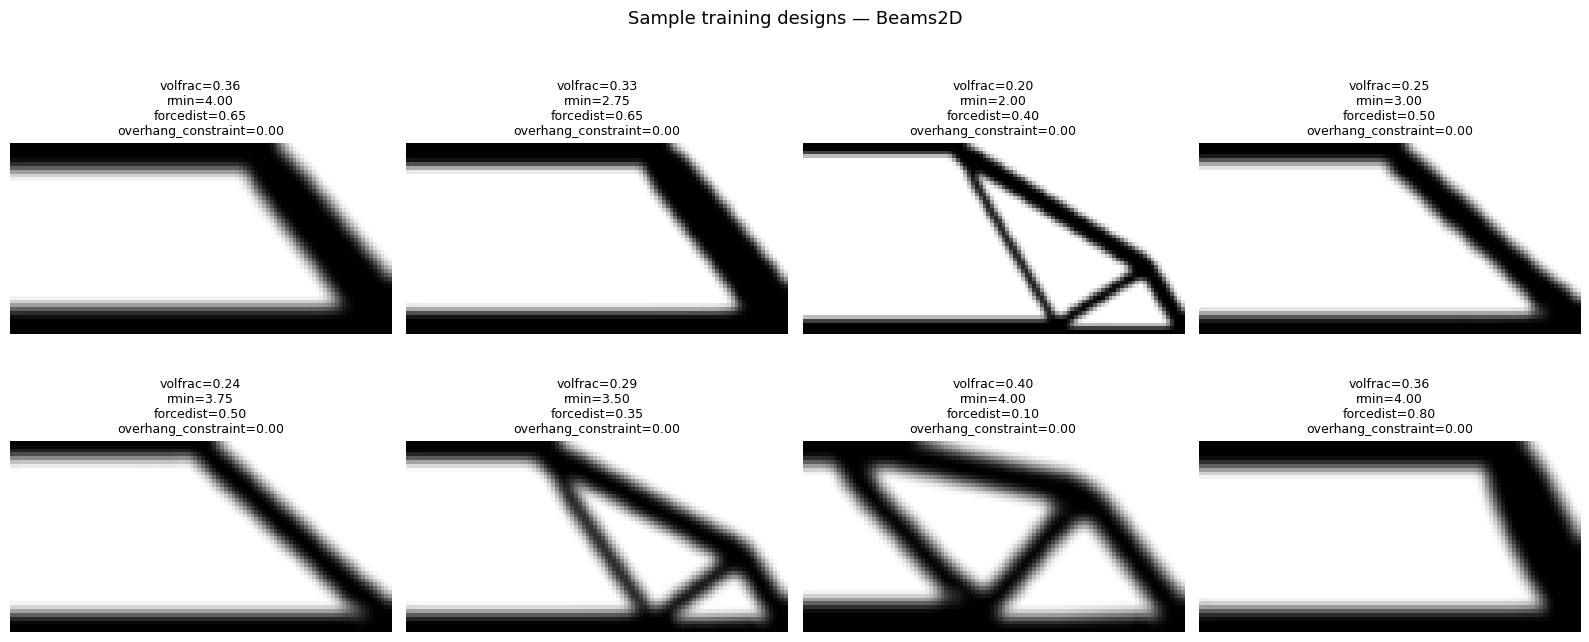

In [86]:
show_design_gallery(dataset, problem, n=8, seed=SEED)

---
## Step 6 — Explore the dataset interactively

**Drag the sliders** to filter designs by condition range. This is the dataset your generative model will learn from.

In [87]:
interactive_condition_explorer(dataset, problem)

HTML(value='<h3>Explore the dataset — drag sliders to filter by condition</h3>')

Output()

---
## Step 7 — Render a single design

EngiBench problems have a built-in `render()` method that draws the design with physics-aware styling.

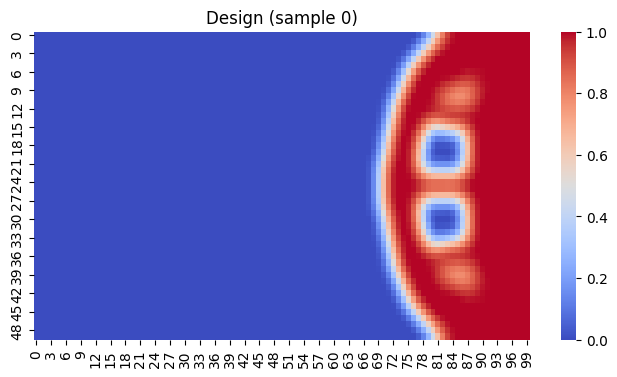

In [89]:
fig = problem.render(design)
plt.title(f"Design (sample {sample_idx})")
plt.show()

---
## Step 8 — Break constraints deliberately

### The EngiBench constraint API

Every EngiBench problem declares **design constraints** — rules a design must satisfy
to be physically valid. The `@constraint` decorator wraps a function that `assert`s
what must be true; `check_constraints()` catches failures and returns a `Violations`
object.

Each constraint is tagged with a **category** that tells you *why* it exists:

| Category | Import | Meaning |
|---|---|---|
| **`THEORY`** | `from engibench.constraint import THEORY` | The constraint comes from **physics**. Values outside the domain are unphysical (e.g. negative volume fraction) but may not crash the solver. |
| **`IMPL`** | `from engibench.constraint import IMPL` | The constraint guards the **implementation**. Violating it causes runtime errors or undefined behavior in the solver (e.g. mesh resolution too small). |

Constraints also have a **criticality** level:
- `Criticality.Error` — hard violation, design is infeasible
- `Criticality.Warning` — soft violation, solver may still run but results are suspect

The `Violations` object returned by `check_constraints()` supports filtering:
```python
violations.by_category(THEORY)      # only physics violations
violations.by_category(IMPL)        # only implementation violations
violations.by_criticality(Criticality.Warning)  # only warnings
```

For example, in `beams2d` the volume fraction has a `THEORY` constraint (physically,
volfrac must be in [0, 1]) **and** a stricter `IMPL` warning (the solver works best
with volfrac in [0.1, 0.9]).

---

### Exercise: force a constraint violation

A design is only valid if it **satisfies all constraints for its operating conditions**. Let's see what happens when we lie about the conditions.

**Your task:** copy the valid `config`, change one **scalar** condition to an extreme value, and call `problem.check_constraints(design=design, config=bad_config)`.

The function returns a `Violations` object — `len(violations) == 0` means no violations.

In [ ]:
# PUBLIC FILL-IN CELL 00-C
# Goal: force a constraint violation and inspect the result.

# Find a scalar condition to perturb
scalar_keys = [k for k in problem.conditions_keys if np.asarray(config[k]).ndim == 0]
perturb_key = scalar_keys[0]
original_val = float(config[perturb_key])

# START FILL ---------------------------------------------------------------
bad_config = dict(config)
bad_config[perturb_key] = original_val * 10  # push it far outside the valid range
# END FILL -----------------------------------------------------------------

print(f"Perturbing '{perturb_key}': {original_val} → {bad_config[perturb_key]}")
violations = problem.check_constraints(design=design, config=bad_config)

print(f"\n--- All constraint checks for {PROBLEM_ID} ({violations.n_constraints} total) ---")
print(f"Violations triggered: {len(violations)}\n")
if violations:
    print(violations)
else:
    print("No violations. Try a more extreme value.")

# CHECKPOINT
assert hasattr(violations, "__len__"), "violations should be a Violations object"
print("\n✅ Checkpoint passed — constraint checking explored.")

---
## Step 9 — Simulate and optimise

Beyond constraint checking, EngiBench problems expose **`simulate()`** and **`optimize()`** methods — the same solvers used to generate the dataset.

| Method | What it does | Returns |
|---|---|---|
| `problem.simulate(design, config)` | Evaluate objective(s) for a given design | `np.ndarray` of objective values |
| `problem.optimize(starting_point, config)` | Run the full optimiser from a starting design | `(optimised_design, optimisation_history)` |

> **Colab note:** some problems (e.g. `heatconduction2d`, `heatconduction3d`, `airfoil`) require a **Docker container** for their solver and will not run on Colab. Problems like `beams2d` and `thermoelastic2d` use pure-Python solvers and work everywhere.

In [ ]:
# Simulate: evaluate the objective for an existing design
obj_values = problem.simulate(design, config)
print(f"Objective values for sample {sample_idx}: {obj_values}")
print(f"Objectives defined: {problem.objectives}")

In [ ]:
# Optimize: run the solver from a uniform starting point
starting_point = np.full(problem.design_space.shape, float(config["volfrac"]))
optimised_design, history = problem.optimize(starting_point, config)

print(f"Optimisation ran for {len(history)} steps")
print(f"Final objective: {history[-1].obj_values}")

# Compare: generated design vs. dataset design
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(design, cmap="gray_r", vmin=0, vmax=1)
axes[0].set_title(f"Dataset design (obj={obj_values[0]:.4f})")
axes[0].axis("off")
axes[1].imshow(optimised_design, cmap="gray_r", vmin=0, vmax=1)
axes[1].set_title(f"Re-optimised (obj={history[-1].obj_values[0]:.4f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

---
## Reflection

Before moving on, think about:

1. **The API contract** — what is *fixed* by the benchmark (design space, conditions, objectives) vs. what is *yours* to choose (model, hyperparameters, training strategy)?
2. **Constraints as a test** — why is it important that `check_constraints` exists as a separate function, rather than just training on feasible data?
3. **Simulate vs. optimise** — `simulate` is cheap (one forward pass), `optimize` is expensive (iterative solver). How might you use each when evaluating a generative model?
4. **What surprised you?** — anything about the design shapes, condition ranges, or dataset size that you did not expect?

---
## Next

Proceed to **Notebook 01** where you will train a generative model on this exact benchmark and produce new designs. The API you just learned carries over unchanged.